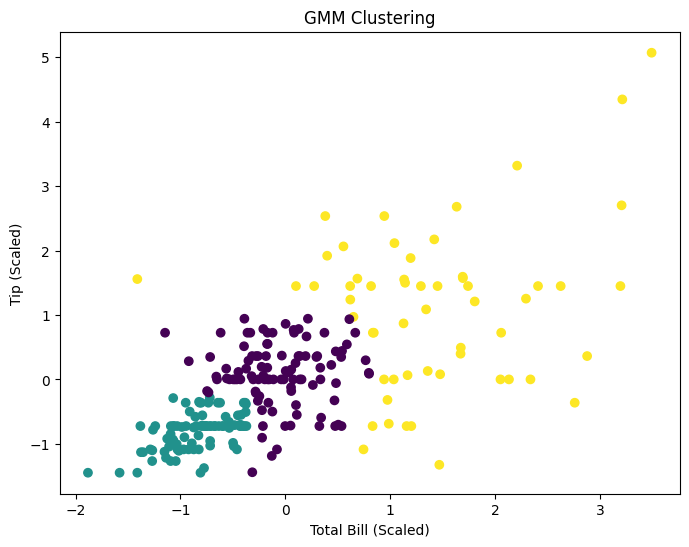

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Load dataset
df = sns.load_dataset('tips')

# Features
X = df[['total_bill', 'tip']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train GMM
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

labels = gmm.fit_predict(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels
)

plt.xlabel("Total Bill (Scaled)")
plt.ylabel("Tip (Scaled)")
plt.title("GMM Clustering")
plt.show()

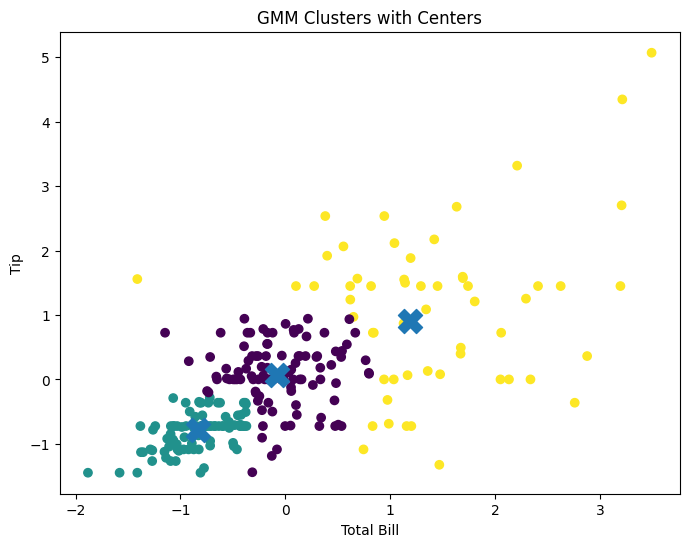

In [3]:
import matplotlib.pyplot as plt

centers = gmm.means_

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=300
)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("GMM Clusters with Centers")
plt.show()

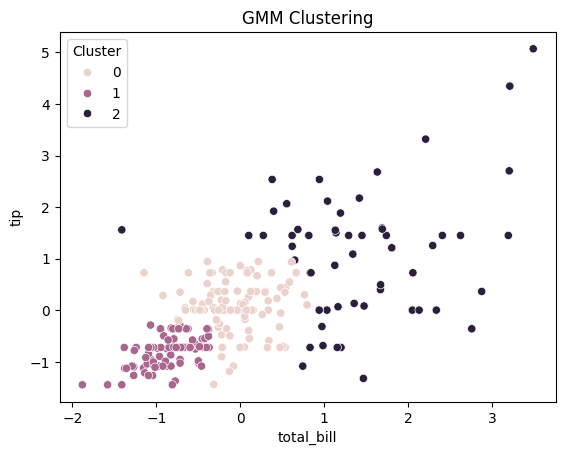

In [5]:
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame({
    'total_bill': X_scaled[:,0],
    'tip': X_scaled[:,1],
    'Cluster': labels
})

sns.scatterplot(
    data=df_plot,
    x='total_bill',
    y='tip',
    hue='Cluster'
)

plt.title("GMM Clustering")
plt.show()

## Hyperparameter Tuning

In [9]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

best_score = -1

for n in range(2, 8):

    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_n = n

print("Best Components:", best_n)
print("Best Silhouette Score:", best_score)

Best Components: 2
Best Silhouette Score: 0.4401536850225068


## Evaluation Metrics
## Silhouette Score

In [7]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.29056480766769754


## Davies-Bouldin Index

In [8]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X_scaled, labels)

print("DBI:", dbi)

DBI: 0.9321547632477695


## Log-Likelihood

In [10]:
print("Log Likelihood:", gmm.score(X_scaled))

Log Likelihood: -2.1270809004843083


## AIC (Akaike Information Criterion) ⭐

In [11]:
aic = gmm.aic(X_scaled)

print("AIC:", aic)

AIC: 1120.0154794363425
